# ML1. Machine Learning Introduction

This notebook is a solution for the School 21 ML1 project.  
Dataset: Kaggle `Two Sigma Connect: Rental Listing Inquiries`, table file `train.json`.

## 1. Introduction

### 1.1 Five examples of ML applications in real life

1. **Spam detection in email.** ML helps filter unwanted messages automatically and saves users time.
2. **Credit scoring in banking.** ML estimates the probability that a client will repay a loan, which helps reduce financial risk.
3. **Medical image analysis.** ML can highlight suspicious areas on X-rays or MRI scans and support doctors in diagnosis.
4. **Recommendation systems.** ML suggests films, music, products, or courses based on user behavior and improves personalization.
5. **Demand forecasting in retail.** ML predicts future sales and helps companies plan stock levels more accurately.

### 1.2 Task classes

Examples from the theory table can be assigned to several ML classes:

| Case | Possible ML task class |
| --- | --- |
| Predict house price | Regression |
| Predict whether a client returns a loan | Binary classification; sometimes regression if predicting expected loss |
| Predict when a patient needs medicine | Classification or regression/time-to-event prediction |
| Choose medicine for a patient | Multiclass classification or recommendation/ranking |
| Choose segment for promo communication | Classification, regression, clustering, uplift modeling |
| Defect recognition from photos | Binary classification |
| Product shelf placement | Regression/optimization, reinforcement learning |
| Search sites for text query | Ranking/information retrieval |
| Split customers into segments | Clustering |
| Detect anomaly in site traffic | Anomaly detection, unsupervised or semi-supervised learning |

The five examples above:

| Example | Task class |
| --- | --- |
| Spam detection | Binary classification |
| Credit scoring | Binary classification or regression |
| Medical image analysis | Classification or segmentation |
| Recommendation systems | Ranking, classification, association rules |
| Demand forecasting | Regression/time series forecasting |

### 1.3 Multiclass vs multilabel

In **multiclass classification**, each object belongs to exactly one class from several possible classes. For example, a fruit is classified as apple, pear, or banana.

In **multilabel classification**, one object can have several labels at the same time. For example, a movie can be both comedy and romance.

### 1.4 House prices: classification or regression?

The house price example is a **regression** problem because the target is a continuous numeric value. It can be reduced to classification by splitting prices into categories, for example `cheap`, `medium`, and `expensive`. However, this loses information because exact numeric differences between prices are replaced with broader classes.

## 2. Introduction to Data Analysis

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    import lightgbm as lgb
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("lightgbm is not installed in this environment. Install it if your Jupyter environment requires a direct import.")

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 100)

In [2]:
def find_train_json():
    candidates = [
        Path("src/train.json"),
        Path("datasets/train.json"),
        Path("data/train.json"),
        Path("train.json"),
        Path("../src/train.json"),
        Path("../datasets/train.json"),
        Path("../data/train.json"),
        Path("../train.json"),
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        "train.json was not found. Download it from Kaggle and place it into datasets/train.json "
        "or data/train.json."
    )


DATA_PATH = find_train_json()
data = pd.read_json(DATA_PATH)
data.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


In [3]:
print(f"Dataset shape: {data.shape[0]} rows, {data.shape[1]} columns")

Dataset shape: 49352 rows, 15 columns


In [4]:
print("Columns:")
print(data.columns.tolist())
print("\nTarget column: price")

Columns:
['bathrooms', 'bedrooms', 'building_id', 'created', 'description', 'display_address', 'features', 'latitude', 'listing_id', 'longitude', 'manager_id', 'photos', 'price', 'street_address', 'interest_level']

Target column: price


In [5]:
data.info()

<class 'pandas.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  str    
 3   created          49352 non-null  str    
 4   description      49352 non-null  str    
 5   display_address  49352 non-null  str    
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  str    
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  str    
 14  interest_level   49352 non-null  str    
dtypes: float64(3), int64(3), object(2), str(7)
memory usage: 6.0+ MB


In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
bathrooms,49352.0,1.212180e+00,0.501420,0.000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+01
bedrooms,49352.0,1.541640e+00,1.115018,0.000,1.000000e+00,1.000000e+00,2.000000e+00,8.000000e+00
latitude,49352.0,4.074154e+01,0.638535,0.000,4.072830e+01,4.075180e+01,4.077430e+01,4.488350e+01
listing_id,49352.0,7.024055e+06,126274.611244,6811957.000,6.915888e+06,7.021070e+06,7.128733e+06,7.753784e+06
longitude,49352.0,-7.395572e+01,1.177912,-118.271,-7.399170e+01,-7.397790e+01,-7.395480e+01,0.000000e+00
price,49352.0,3.830174e+03,22066.865885,43.000,2.500000e+03,3.150000e+03,4.100000e+03,4.490000e+06


In [7]:
non_numeric_overview = pd.DataFrame(
    {
        "dtype": data.select_dtypes(exclude=np.number).dtypes.astype(str),
        "non_null": data.select_dtypes(exclude=np.number).notna().sum(),
        "sample_value": data.select_dtypes(exclude=np.number).iloc[0].astype(str),
    }
)
non_numeric_overview

,dtype,non_null,sample_value
building_id,str,49352,8579a0b0d54db803821a35a4a615e97a
created,str,49352,2016-06-16 05:55:27
description,str,49352,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...
display_address,str,49352,145 Borinquen Place
features,object,49352,"['Dining Room', 'Pre-War', 'Laundry in Buildin..."
manager_id,str,49352,a10db4590843d78c784171a107bdacb4
photos,object,49352,['https://photos.renthop.com/2/7170325_3bb5ac8...
street_address,str,49352,145 Borinquen Place
interest_level,str,49352,medium


In [8]:
numeric_corr = data.select_dtypes(include=np.number).corr(numeric_only=True)
numeric_corr

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


In [9]:
missing_summary = (
    data.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)
missing_summary["missing_percent"] = missing_summary["missing_count"] / len(data) * 100
missing_summary.head(20)

,missing_count,missing_percent
bathrooms,0,0.0
bedrooms,0,0.0
building_id,0,0.0
created,0,0.0
description,0,0.0
display_address,0,0.0
features,0,0.0
latitude,0,0.0
listing_id,0,0.0
longitude,0,0.0


### 2.5 Quick analysis notes

For the original Kaggle `train.json`, the expected size is **49352 rows and 15 columns**.

`info()` shows column types and non-null counts. It helps identify categorical columns, numeric columns, and missing values.

`describe()` gives basic descriptive statistics. For numeric columns, it shows mean, standard deviation, min/max, and quartiles. For object columns, it shows the number of unique values and the most frequent value.

`corr()` shows linear correlations between numeric columns. A value close to `1` means strong positive linear correlation, close to `-1` means strong negative linear correlation, and close to `0` means weak linear correlation.

The missing-value table above shows whether there are empty values. In the original table, there are no completely empty columns. Many text/list columns can contain empty strings or empty lists rather than `NaN`, so it is useful to inspect both missing values and actual content.

In [10]:
work_data = data[["bathrooms", "bedrooms", "interest_level", "price"]].copy()
work_data.head()

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795


## 3. Statistical Data Analysis

### 3.3 Target analysis

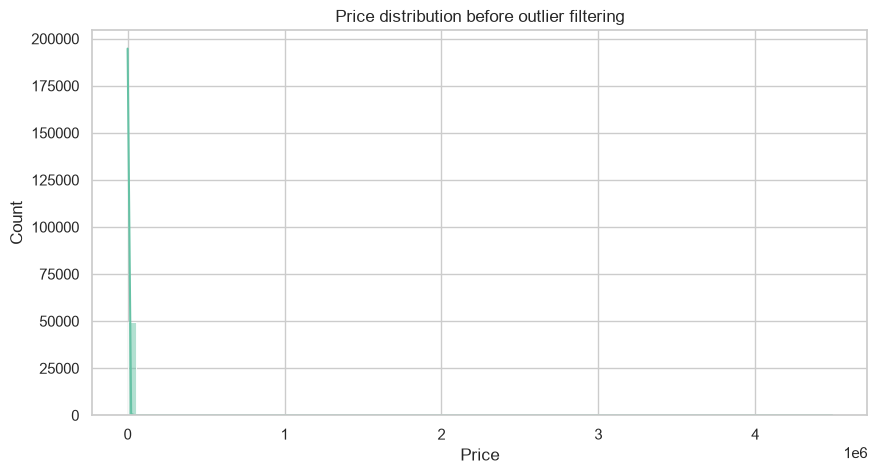

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(work_data["price"], bins=80, kde=True)
plt.title("Price distribution before outlier filtering")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

The first histogram usually has a long right tail: most rental prices are concentrated in a lower range, while a small number of very expensive listings stretch the scale.

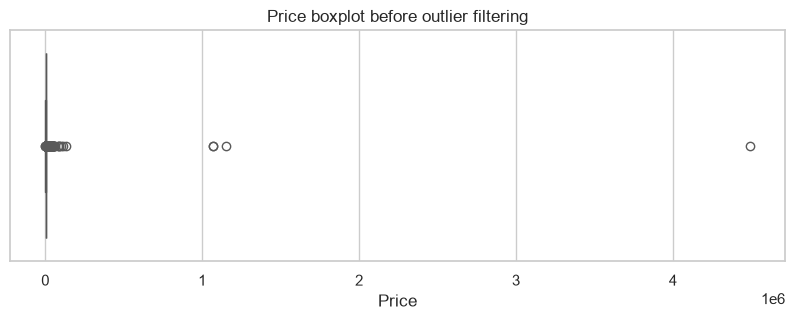

In [12]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=work_data["price"])
plt.title("Price boxplot before outlier filtering")
plt.xlabel("Price")
plt.show()

The boxplot makes outliers visible. Prices far above the upper whisker are likely luxury listings, data errors, or rare cases. They can strongly affect simple models and visualizations.

In [13]:
lower_price = work_data["price"].quantile(0.01)
upper_price = work_data["price"].quantile(0.99)

filtered_data = work_data[
    work_data["price"].between(lower_price, upper_price)
].copy()

print(f"1st percentile: {lower_price:.2f}")
print(f"99th percentile: {upper_price:.2f}")
print(f"Rows before filtering: {len(work_data)}")
print(f"Rows after filtering: {len(filtered_data)}")

1st percentile: 1475.00
99th percentile: 13000.00
Rows before filtering: 49352
Rows after filtering: 48379


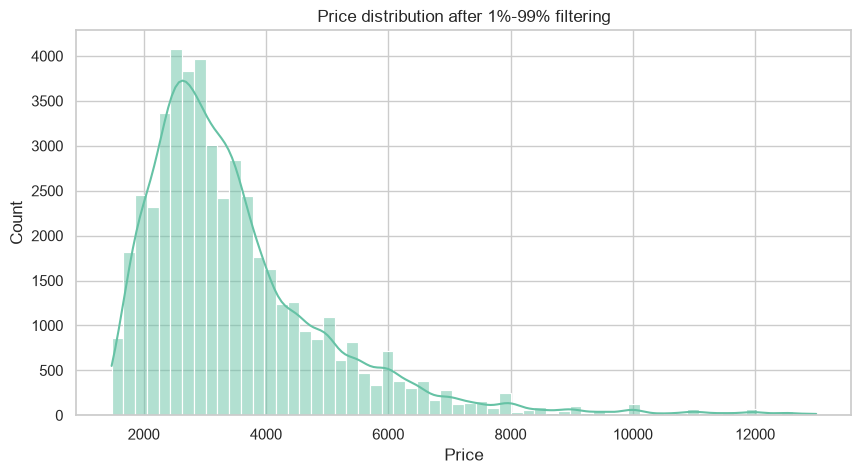

In [14]:
plt.figure(figsize=(10, 5))
sns.histplot(filtered_data["price"], bins=60, kde=True)
plt.title("Price distribution after 1%-99% filtering")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

After removing the lowest 1% and highest 1% of prices, the distribution becomes easier to read. The target is still right-skewed, but extreme values no longer dominate the plot.

### 3.4 Characteristics analysis

In [15]:
print(f"interest_level dtype: {filtered_data['interest_level'].dtype}")

interest_level dtype: str


In [16]:
filtered_data["interest_level"].value_counts()

interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64

In [17]:
interest_level_map = {"low": 0, "medium": 1, "high": 2}
filtered_data["interest_level_encoded"] = filtered_data["interest_level"].map(interest_level_map)
filtered_data.head()

,bathrooms,bedrooms,interest_level,price,interest_level_encoded
4,1.0,1,medium,2400,1
6,1.0,2,low,3800,0
9,1.0,2,medium,3495,1
10,1.5,3,medium,3000,1
15,1.0,0,low,2795,0


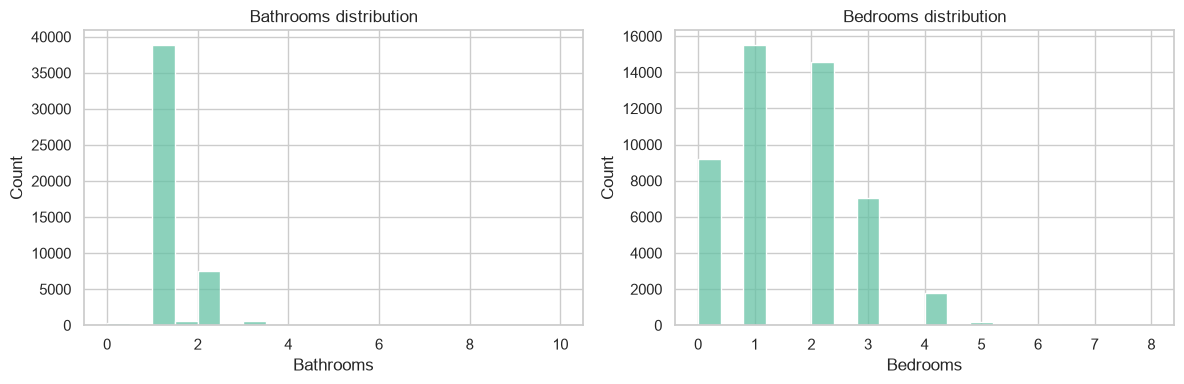

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(filtered_data["bathrooms"], bins=20, ax=axes[0])
axes[0].set_title("Bathrooms distribution")
axes[0].set_xlabel("Bathrooms")

sns.histplot(filtered_data["bedrooms"], bins=20, ax=axes[1])
axes[1].set_title("Bedrooms distribution")
axes[1].set_xlabel("Bedrooms")

plt.tight_layout()
plt.show()

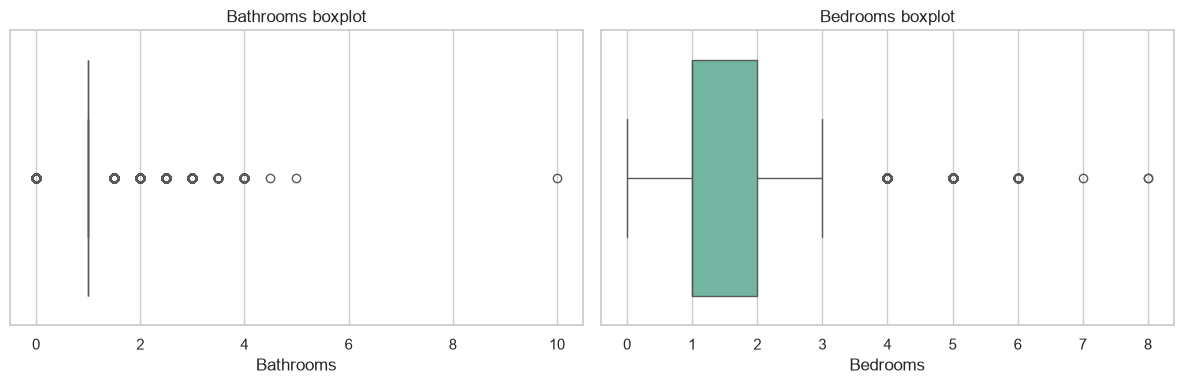

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=filtered_data["bathrooms"], ax=axes[0])
axes[0].set_title("Bathrooms boxplot")
axes[0].set_xlabel("Bathrooms")

sns.boxplot(x=filtered_data["bedrooms"], ax=axes[1])
axes[1].set_title("Bedrooms boxplot")
axes[1].set_xlabel("Bedrooms")

plt.tight_layout()
plt.show()

`interest_level` is a categorical column with string values. It is encoded as `low = 0`, `medium = 1`, `high = 2` so it can be used in correlation analysis and simple numeric models.

After filtering `price` by the 1st and 99th percentiles, the expected value counts are approximately `low = 33697`, `medium = 11116`, and `high = 3566`.

The histograms and boxplots for `bathrooms` and `bedrooms` usually show that most listings have small values. According to the project checklist, there are no critical outliers for these two features after the main target filtering step.

### 3.5 Complex analysis

In [20]:
corr_columns = ["bathrooms", "bedrooms", "interest_level_encoded", "price"]
corr_matrix = filtered_data[corr_columns].corr()
corr_matrix

,bathrooms,bedrooms,interest_level_encoded,price
bathrooms,1.000000,0.517574,-0.063635,0.671943
bedrooms,0.517574,1.000000,0.050654,0.545948
interest_level_encoded,-0.063635,0.050654,1.000000,-0.200111
price,0.671943,0.545948,-0.200111,1.000000


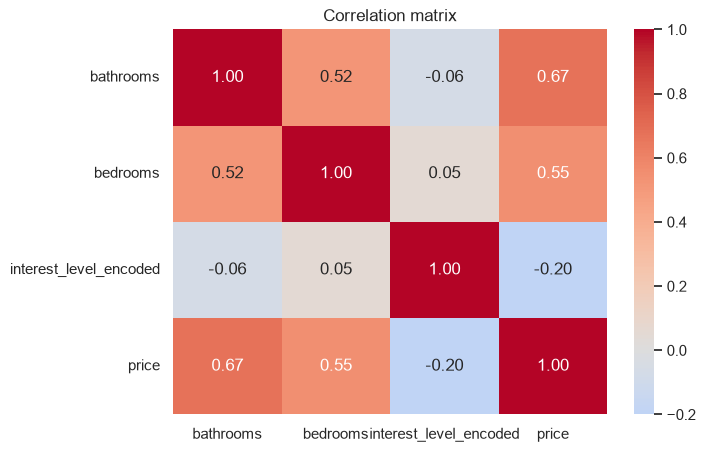

In [21]:
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation matrix")
plt.show()

The heatmap shows linear relationships between features and price. In this small feature set, correlations are usually present but not very strong. Among the basic features, `bathrooms` usually has the strongest correlation with `price`, but `bathrooms` and `bedrooms` alone cannot fully explain rental price.

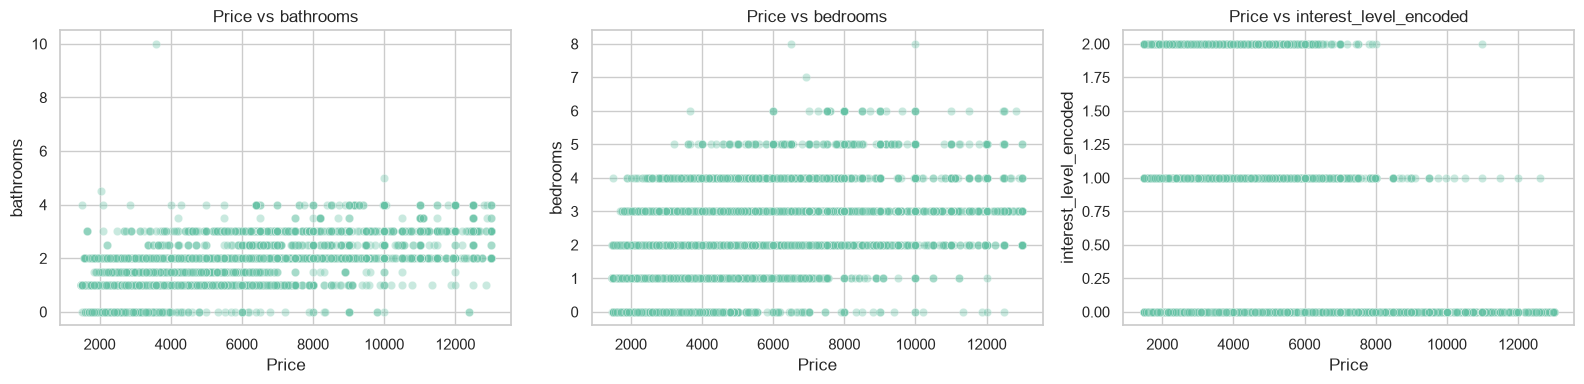

In [22]:
features_for_scatter = ["bathrooms", "bedrooms", "interest_level_encoded"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feature in zip(axes, features_for_scatter):
    sns.scatterplot(data=filtered_data, x="price", y=feature, alpha=0.35, ax=ax)
    ax.set_title(f"Price vs {feature}")
    ax.set_xlabel("Price")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.show()

## 4. Creating Features

In [23]:
feature_data = filtered_data.copy()
feature_data["bathrooms_squared"] = feature_data["bathrooms"] ** 2
feature_data["bedrooms_squared"] = feature_data["bedrooms"] ** 2
feature_data["interest_level_squared"] = feature_data["interest_level_encoded"] ** 2

created_feature_columns = [
    "bathrooms",
    "bedrooms",
    "interest_level_encoded",
    "bathrooms_squared",
    "bedrooms_squared",
    "interest_level_squared",
    "price",
]

created_corr = feature_data[created_feature_columns].corr()
created_corr

,bathrooms,bedrooms,interest_level_encoded,bathrooms_squared,bedrooms_squared,interest_level_squared,price
bathrooms,1.000000,0.517574,-0.063635,0.956023,0.548760,-0.059410,0.671943
bedrooms,0.517574,1.000000,0.050654,0.478817,0.928277,0.039511,0.545948
interest_level_encoded,-0.063635,0.050654,1.000000,-0.068558,0.046340,0.944013,-0.200111
bathrooms_squared,0.956023,0.478817,-0.068558,1.000000,0.522227,-0.062240,0.648486
bedrooms_squared,0.548760,0.928277,0.046340,0.522227,1.000000,0.035718,0.543406
interest_level_squared,-0.059410,0.039511,0.944013,-0.062240,0.035718,1.000000,-0.182672
price,0.671943,0.545948,-0.200111,0.648486,0.543406,-0.182672,1.000000


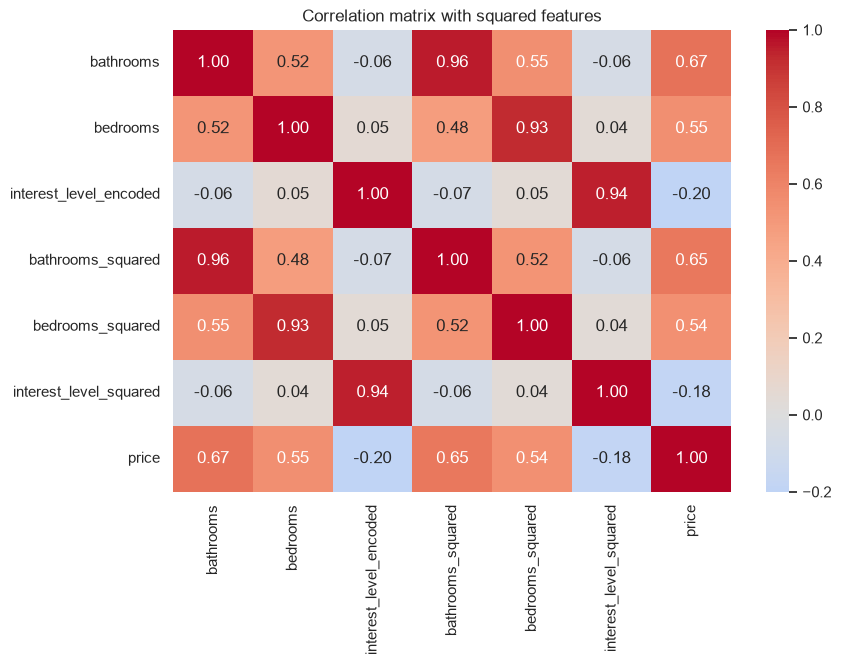

In [24]:
plt.figure(figsize=(9, 6))
sns.heatmap(created_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation matrix with squared features")
plt.show()

In [25]:
target_corr = created_corr["price"].drop("price").sort_values(key=lambda s: s.abs(), ascending=False)
target_corr

bathrooms                 0.671943
bathrooms_squared         0.648486
bedrooms                  0.545948
bedrooms_squared          0.543406
interest_level_encoded   -0.200111
interest_level_squared   -0.182672
Name: price, dtype: float64

Squared features can change the correlation with price because they emphasize larger values. In the expected project result, squared features do not show higher correlation with `price` than the original basic features. Correlation alone is not enough to prove that a feature improves model quality.

In [26]:
X = filtered_data[["bathrooms", "bedrooms"]].copy()
y = filtered_data["price"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=21,
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (36284, 2)
X_test shape: (12095, 2)
y_train shape: (36284,)
y_test shape: (12095,)


In [27]:
poly = PolynomialFeatures(degree=10, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(f"Polynomial train shape: {X_train_poly.shape}")
print(f"Polynomial test shape: {X_test_poly.shape}")

Polynomial train shape: (36284, 65)
Polynomial test shape: (12095, 65)


## 5. Models

In [28]:
result_MAE = pd.DataFrame(columns=["model", "train", "test"])
result_RMSE = pd.DataFrame(columns=["model", "train", "test"])


def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5


def add_metrics(model_name, y_train_true, y_train_pred, y_test_true, y_test_pred):
    global result_MAE, result_RMSE
    result_MAE.loc[len(result_MAE)] = [
        model_name,
        mean_absolute_error(y_train_true, y_train_pred),
        mean_absolute_error(y_test_true, y_test_pred),
    ]
    result_RMSE.loc[len(result_RMSE)] = [
        model_name,
        rmse(y_train_true, y_train_pred),
        rmse(y_test_true, y_test_pred),
    ]

### 5.2 Linear Regression

In [29]:
linear_regression = LinearRegression()
linear_regression.fit(X_train_poly, y_train)

train_linear_pred = linear_regression.predict(X_train_poly)
test_linear_pred = linear_regression.predict(X_test_poly)

train_predictions = X_train.copy()
test_predictions = X_test.copy()
train_predictions["target"] = y_train
test_predictions["target"] = y_test

train_predictions["linear_regression_prediction"] = train_linear_pred
test_predictions["linear_regression_prediction"] = test_linear_pred

add_metrics(
    "linear_regression",
    y_train,
    train_linear_pred,
    y_test,
    test_linear_pred,
)

result_MAE, result_RMSE

(               model       train        test
 0  linear_regression  850.623357  890.041006,
                model        train         test
 0  linear_regression  1210.468895  4225.497632)

### 5.3 Decision Tree

In [30]:
decision_tree = DecisionTreeRegressor(random_state=21)
decision_tree.fit(X_train, y_train)

train_tree_pred = decision_tree.predict(X_train)
test_tree_pred = decision_tree.predict(X_test)

train_predictions["decision_tree_prediction"] = train_tree_pred
test_predictions["decision_tree_prediction"] = test_tree_pred

add_metrics(
    "decision_tree",
    y_train,
    train_tree_pred,
    y_test,
    test_tree_pred,
)

result_MAE, result_RMSE

(               model       train        test
 0  linear_regression  850.623357  890.041006
 1      decision_tree  754.307420  760.636259,
                model        train         test
 0  linear_regression  1210.468895  4225.497632
 1      decision_tree  1073.448694  1092.198978)

### 5.4 Naive Models

In [31]:
train_mean_price = y_train.mean()
train_median_price = y_train.median()

train_mean_pred = np.full(shape=len(y_train), fill_value=train_mean_price)
test_mean_pred = np.full(shape=len(y_test), fill_value=train_mean_price)

train_median_pred = np.full(shape=len(y_train), fill_value=train_median_price)
test_median_pred = np.full(shape=len(y_test), fill_value=train_median_price)

train_predictions["naive_mean_prediction"] = train_mean_pred
test_predictions["naive_mean_prediction"] = test_mean_pred
train_predictions["naive_median_prediction"] = train_median_pred
test_predictions["naive_median_prediction"] = test_median_pred

add_metrics("naive_mean", y_train, train_mean_pred, y_test, test_mean_pred)
add_metrics("naive_median", y_train, train_median_pred, y_test, test_median_pred)

result_MAE, result_RMSE

(               model        train         test
 0  linear_regression   850.623357   890.041006
 1      decision_tree   754.307420   760.636259
 2         naive_mean  1140.870760  1136.279866
 3       naive_median  1087.823448  1081.371807,
                model        train         test
 0  linear_regression  1210.468895  4225.497632
 1      decision_tree  1073.448694  1092.198978
 2         naive_mean  1597.206158  1598.972298
 3       naive_median  1644.278294  1644.110870)

### 5.5 Compare results

In [32]:
result_MAE

,model,train,test
0,linear_regression,850.623357,890.041006
1,decision_tree,754.307420,760.636259
2,naive_mean,1140.870760,1136.279866
3,naive_median,1087.823448,1081.371807


In [33]:
result_RMSE

,model,train,test
0,linear_regression,1210.468895,4225.497632
1,decision_tree,1073.448694,1092.198978
2,naive_mean,1597.206158,1598.972298
3,naive_median,1644.278294,1644.110870


In [34]:
best_mae_model = result_MAE.sort_values("test").iloc[0]
best_rmse_model = result_RMSE.sort_values("test").iloc[0]

print(f"Best model by test MAE: {best_mae_model['model']} ({best_mae_model['test']:.2f})")
print(f"Best model by test RMSE: {best_rmse_model['model']} ({best_rmse_model['test']:.2f})")

Best model by test MAE: decision_tree (760.64)
Best model by test RMSE: decision_tree (1092.20)


The best model is the one with the lowest test error. Test metrics are more important than train metrics because they estimate performance on unseen data.

With only `bathrooms` and `bedrooms`, model quality is expected to be limited. Rental price also depends on location, listing text, photos, building features, and many other variables.

## Additional practice

In [35]:
additional_data = data.copy()

additional_data["description_length"] = additional_data["description"].fillna("").str.len()
additional_data["features_count"] = additional_data["features"].apply(lambda x: len(x) if isinstance(x, list) else 0)
additional_data["photos_count"] = additional_data["photos"].apply(lambda x: len(x) if isinstance(x, list) else 0)
additional_data["created"] = pd.to_datetime(additional_data["created"], errors="coerce")
additional_data["created_month"] = additional_data["created"].dt.month
additional_data["created_dayofweek"] = additional_data["created"].dt.dayofweek

additional_columns = [
    "bathrooms",
    "bedrooms",
    "latitude",
    "longitude",
    "description_length",
    "features_count",
    "photos_count",
    "created_month",
    "created_dayofweek",
    "price",
]

additional_data[additional_columns].head()

,bathrooms,bedrooms,latitude,longitude,description_length,features_count,photos_count,created_month,created_dayofweek,price
4,1.0,1,40.7108,-73.9539,553,7,12,6,3,2400
6,1.0,2,40.7513,-73.9722,827,6,6,6,2,3800
9,1.0,2,40.7575,-73.9625,799,6,6,6,1,3495
10,1.5,3,40.7145,-73.9425,588,0,5,6,4,3000
15,1.0,0,40.7439,-73.9743,344,4,4,6,1,2795
